# Analytics Journey

The previous notebooks progressively transformed raw border transaction data into actionable intelligence.

### Questions Answered So Far

- **What happened?**  
  Business Insights identified key patterns in trade transactions, customs revenue, border operations, and commodity movements.

- **Where did it happen?**  
  Geospatial Analytics visualized the spatial distribution of border activities, operational hotspots, and regional trade corridors.

- **What is the trend?**  
  Time Series Forecasting examined historical revenue patterns and estimated future trends to support strategic planning.

- **How are we performing?**  
  Executive KPI Dashboard measured operational performance using key indicators such as customs revenue, queue length, processing time, inspection outcomes, and border efficiency.

---

## The Next Business Question

Having understood historical performance and operational trends, the next step is to determine:

> **Which border posts require immediate management attention?**

To answer this question, this notebook develops a **Border Performance Scorecard** that evaluates each border post using multiple operational indicators and ranks performance to support intelligence-led decision-making, resource allocation, and strategic border management.

# ECOWAS Border Intelligence Analytics Platform (EBIAP)

# Border Performance Scorecard

## Impact Assessment of Simulated Regional Trade Diversion Following the AES Countries' Withdrawal from ECOWAS

### Case Study: Tsamiya–Kamba Transit Corridor

---

# Objective

This notebook develops an executive Border Performance Scorecard that evaluates operational performance across border posts using multiple performance indicators.

The scorecard supports intelligence-led decision-making by identifying high-performing border posts and those requiring management intervention.

---

# Performance Indicators

The scorecard evaluates each border post using:

- Border Efficiency Score
- Average Queue Length
- Average Processing Time
- Customs Revenue
- Security Incidents
- Smuggling Risk

---

# Expected Outputs

- Border performance scorecard
- Performance ranking
- Operational categories
- Executive recommendations
- Dashboard-ready reports

In [56]:
# ============================================================
# Chapter 1 - Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [57]:
# ============================================================
# Chapter 2 - Load Dataset
# ============================================================

df = pd.read_csv("trade_diversion_transactions.csv")

print(df.shape)

df.head()

(100000, 20)


,Transaction_ID,Transaction_Date,Period,Origin_Country,Entry_Country,Destination_Country,Border_Post,Commodity,Vehicle_Type,Cargo_Weight_kg,Trade_Value_USD,Customs_Duty_USD,Revenue_Collected_USD,Queue_Length,Processing_Time_Minutes,Inspection_Result,Smuggling_Risk,Security_Incident,Scanner_Status,Border_Efficiency_Score
0,TRX0000001,2025-08-02,After Diversion,Togo,Cape Verde,Niger,Praia Port,Vehicles,Heavy Truck,23091.78,70960.57,9435.26,9791.44,17,25.9,Passed,Medium,No,Unavailable,98.0
1,TRX0000002,2022-08-17,Before Diversion,Nigeria,Togo,Niger,Kodjoviakope,Livestock,Heavy Truck,16533.94,63340.83,11608.49,11799.07,22,48.0,Passed,Low,No,Unavailable,82.3
2,TRX0000003,2022-02-21,Before Diversion,Benin,Benin,Niger,Hillacondji,Vehicles,Passenger Bus,943.86,13943.07,2766.44,2833.49,25,46.5,Passed,Medium,No,Unavailable,76.8
3,TRX0000004,2023-07-18,Before Diversion,Benin,Sierra Leone,Nigeria,Gbalamuya,Petroleum,Heavy Truck,18142.28,83276.36,13714.69,13775.83,6,20.5,Passed,Medium,No,Available,95.3
4,TRX0000005,2023-05-17,Before Diversion,Benin,Mali,Nigeria,Gogui,Vehicles,Heavy Truck,19017.79,62190.16,10388.67,10554.40,26,54.9,Passed,Low,No,Available,79.7


## Border Performance Indicators

Aggregate key operational metrics for each border post.

In [58]:
# ============================================================
# Chapter 3 - Border Performance Summary
# ============================================================

scorecard = (

    df.groupby("Border_Post")

    .agg(

        Transactions=("Transaction_ID","count"),

        Revenue=("Revenue_Collected_USD","sum"),

        Trade_Value=("Trade_Value_USD","sum"),

        Avg_Queue=("Queue_Length","mean"),

        Avg_Processing=("Processing_Time_Minutes","mean"),

        Avg_Efficiency=("Border_Efficiency_Score","mean"),

        High_Risk=("Smuggling_Risk",
                   lambda x: (x=="High").sum()),

        Security_Incidents=("Security_Incident",
                            lambda x: (x=="Yes").sum())

    )

    .round(2)

)

scorecard

,Transactions,Revenue,Trade_Value,Avg_Queue,Avg_Processing,Avg_Efficiency,High_Risk,Security_Incidents
Border_Post,,,,,,,,
Aflao,2612,18425257.09,1.405737e+08,22.57,44.31,83.19,659,234
Amdallai,3031,20662748.43,1.608466e+08,22.32,43.86,83.34,749,252
Bo Waterside,3540,24217075.11,1.897958e+08,22.73,44.71,83.09,911,301
Cinkanse,5504,37720302.83,2.903418e+08,22.55,44.34,83.21,1355,498
Elubo,2706,18308650.53,1.433368e+08,22.70,44.27,83.25,721,241
Gaya,5338,37357217.26,2.867480e+08,22.50,44.14,83.30,1354,485
Gbalamuya,3468,23821839.56,1.851335e+08,22.74,44.64,83.16,860,286
Gogui,5466,37039457.22,2.900902e+08,22.61,44.47,83.14,1360,465
Hillacondji,6611,45471352.72,3.540514e+08,22.61,44.44,83.21,1758,549


## Composite Performance Score

Develop a composite operational score using efficiency, queue length, processing time, security incidents, and high-risk transactions.

This score enables comparison across border posts.

In [59]:
# ============================================================
# Chapter 4 - Composite Performance Score
# ============================================================

scorecard["Performance_Score"] = (

    scorecard["Avg_Efficiency"]

    - (scorecard["Avg_Queue"] * 0.30)

    - (scorecard["Avg_Processing"] * 0.20)

    - (scorecard["Security_Incidents"] * 0.02)

    - (scorecard["High_Risk"] * 0.01)

).round(2)

scorecard.head()

,Transactions,Revenue,Trade_Value,Avg_Queue,Avg_Processing,Avg_Efficiency,High_Risk,Security_Incidents,Performance_Score
Border_Post,,,,,,,,,
Aflao,2612,18425257.09,1.405737e+08,22.57,44.31,83.19,659,234,56.29
Amdallai,3031,20662748.43,1.608466e+08,22.32,43.86,83.34,749,252,55.34
Bo Waterside,3540,24217075.11,1.897958e+08,22.73,44.71,83.09,911,301,52.20
Cinkanse,5504,37720302.83,2.903418e+08,22.55,44.34,83.21,1355,498,44.07
Elubo,2706,18308650.53,1.433368e+08,22.70,44.27,83.25,721,241,55.56


## Performance Ranking

Rank border posts according to the composite performance score.

In [60]:
# ============================================================
# Chapter 5 - Border Ranking
# ============================================================

scorecard = scorecard.sort_values(

    by="Performance_Score",

    ascending=False

)

scorecard

,Transactions,Revenue,Trade_Value,Avg_Queue,Avg_Processing,Avg_Efficiency,High_Risk,Security_Incidents,Performance_Score
Border_Post,,,,,,,,,
Jibia,2288,15509998.32,1.213439e+08,22.46,44.35,83.15,590,196,57.72
Illela,2636,18387635.49,1.413604e+08,22.12,43.75,83.56,654,244,56.75
Praia Port,2451,16670672.17,1.305909e+08,22.46,44.29,83.23,625,235,56.68
Paga,2713,18514492.85,1.447276e+08,22.49,44.17,83.33,678,223,56.51
Aflao,2612,18425257.09,1.405737e+08,22.57,44.31,83.19,659,234,56.29
Elubo,2706,18308650.53,1.433368e+08,22.70,44.27,83.25,721,241,55.56
Amdallai,3031,20662748.43,1.608466e+08,22.32,43.86,83.34,749,252,55.34
Noe,2898,20093601.73,1.550424e+08,22.38,43.97,83.37,751,251,55.33
Sao Domingos,2970,20292146.36,1.566466e+08,22.46,44.11,83.40,782,249,55.04


In [61]:
# Convert Border_Post from index to a regular column
scorecard = scorecard.reset_index()

# ============================================================
# Chapter 5 - Border Ranking
# ============================================================

scorecard = scorecard.sort_values(

    by="Performance_Score",

    ascending=False

)

scorecard

In [62]:
# ============================================================
# Chapter 6 - Performance Classification
# ============================================================

def classify(score):

    if score >= 55:
        return "Excellent"

    elif score >= 45:
        return "Good"

    elif score >= 35:
        return "Needs Improvement"

    else:
        return "Critical"

scorecard["Performance_Category"] = (
    scorecard["Performance_Score"]
    .apply(classify)
)

scorecard.head()

,Border_Post,Transactions,Revenue,Trade_Value,Avg_Queue,Avg_Processing,Avg_Efficiency,High_Risk,Security_Incidents,Performance_Score,Performance_Category
0,Jibia,2288,15509998.32,1.213439e+08,22.46,44.35,83.15,590,196,57.72,Excellent
1,Illela,2636,18387635.49,1.413604e+08,22.12,43.75,83.56,654,244,56.75,Excellent
2,Praia Port,2451,16670672.17,1.305909e+08,22.46,44.29,83.23,625,235,56.68,Excellent
3,Paga,2713,18514492.85,1.447276e+08,22.49,44.17,83.33,678,223,56.51,Excellent
4,Aflao,2612,18425257.09,1.405737e+08,22.57,44.31,83.19,659,234,56.29,Excellent


## Distribution of Performance Categories

This analysis summarizes the number of border posts within each operational performance category.

The distribution provides management with an overview of the overall health of the border network.

In [63]:
# ============================================================
# Chapter 7 - Performance Distribution
# ============================================================

performance_distribution = (

    scorecard["Performance_Category"]

    .value_counts()

)

performance_distribution

,count
Performance_Category,
Excellent,9
Needs Improvement,6
Good,5
Critical,4


## Performance Category Visualization

Visualize the distribution of border performance classifications across all border posts.

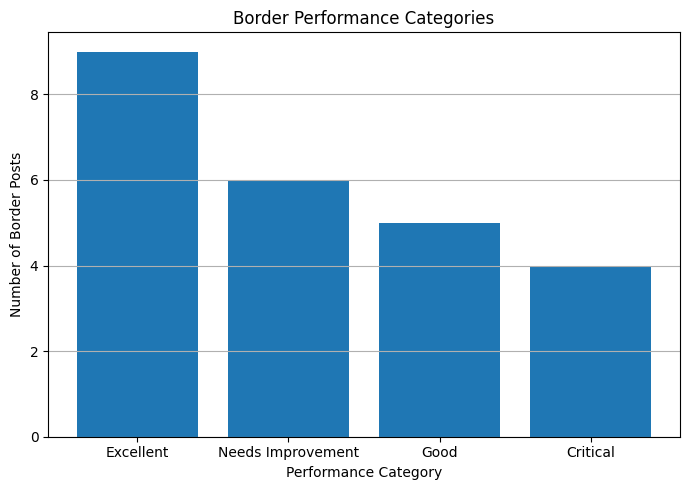

In [64]:
# ============================================================
# Chapter 8 - Performance Category Chart
# ============================================================

plt.figure(figsize=(7,5))

plt.bar(

    performance_distribution.index,

    performance_distribution.values

)

plt.title("Border Performance Categories")

plt.xlabel("Performance Category")

plt.ylabel("Number of Border Posts")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

## Top Performing Border Posts

Identify the highest-performing border posts according to the composite performance score.

These border posts may represent operational best practices that can be replicated across the region.

In [65]:
# ============================================================
# Chapter 9 - Top Performers
# ============================================================

top_borders = (

    scorecard

    .head(10)

)

top_borders

,Border_Post,Transactions,Revenue,Trade_Value,Avg_Queue,Avg_Processing,Avg_Efficiency,High_Risk,Security_Incidents,Performance_Score,Performance_Category
0,Jibia,2288,15509998.32,1.213439e+08,22.46,44.35,83.15,590,196,57.72,Excellent
1,Illela,2636,18387635.49,1.413604e+08,22.12,43.75,83.56,654,244,56.75,Excellent
2,Praia Port,2451,16670672.17,1.305909e+08,22.46,44.29,83.23,625,235,56.68,Excellent
3,Paga,2713,18514492.85,1.447276e+08,22.49,44.17,83.33,678,223,56.51,Excellent
4,Aflao,2612,18425257.09,1.405737e+08,22.57,44.31,83.19,659,234,56.29,Excellent
5,Elubo,2706,18308650.53,1.433368e+08,22.70,44.27,83.25,721,241,55.56,Excellent
6,Amdallai,3031,20662748.43,1.608466e+08,22.32,43.86,83.34,749,252,55.34,Excellent
7,Noe,2898,20093601.73,1.550424e+08,22.38,43.97,83.37,751,251,55.33,Excellent
8,Sao Domingos,2970,20292146.36,1.566466e+08,22.46,44.11,83.40,782,249,55.04,Excellent
9,Pogo,2988,20295565.32,1.596707e+08,22.66,44.58,83.17,779,245,54.77,Good


## Border Performance Ranking

Compare the operational performance of the top-performing border posts using the composite performance score.

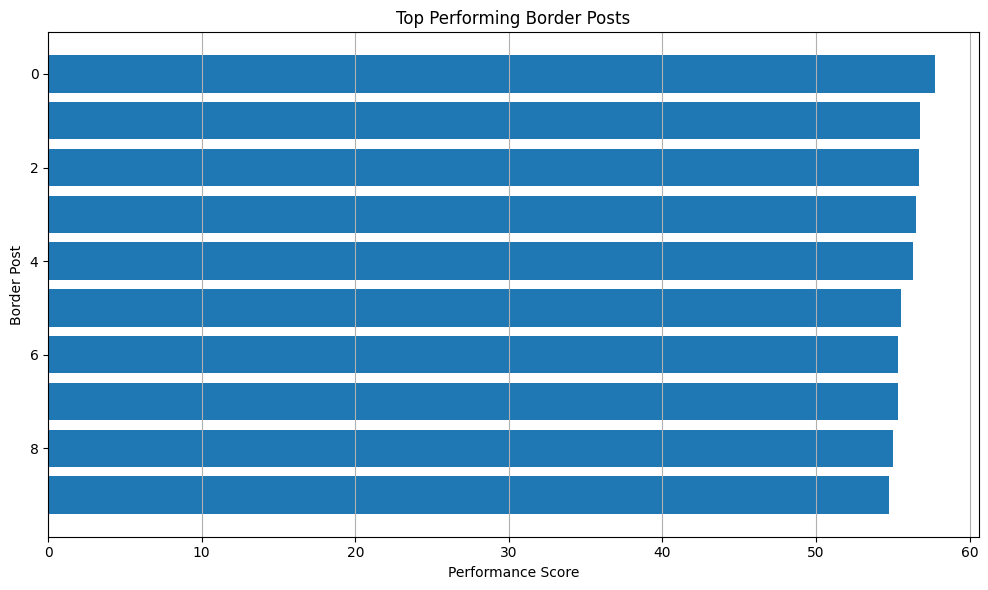

In [66]:
# ============================================================
# Chapter 10 - Performance Ranking Chart
# ============================================================

plt.figure(figsize=(10,6))

plt.barh(

    top_borders.index,

    top_borders["Performance_Score"]

)

plt.title("Top Performing Border Posts")

plt.xlabel("Performance Score")

plt.ylabel("Border Post")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.tight_layout()

plt.show()

## Border Posts Requiring Immediate Attention

While high-performing border posts demonstrate operational excellence, identifying underperforming locations is equally important.

This analysis highlights border posts with the lowest composite performance scores. These locations may require additional staffing, infrastructure improvements, process optimization, or enhanced security measures.

The results support evidence-based resource allocation and operational planning.

In [67]:
# ============================================================
# Chapter 11 - Lowest Performing Border Posts
# ============================================================

bottom_borders = (

    scorecard

    .sort_values(

        by="Performance_Score",

        ascending=True

    )

    .head(10)

)

bottom_borders

,Border_Post,Transactions,Revenue,Trade_Value,Avg_Queue,Avg_Processing,Avg_Efficiency,High_Risk,Security_Incidents,Performance_Score,Performance_Category
23,Tsamiya,6395,43904800.29,3.412729e+08,71.71,108.03,53.29,1591,547,-16.68,Critical
22,Kamba,4895,33655170.00,2.628111e+08,69.27,105.14,54.65,1211,432,-7.91,Critical
21,Malanville,6633,45736299.53,3.553884e+08,45.14,73.59,69.42,1624,580,13.32,Critical
20,Seme,3520,23695650.77,1.835372e+08,45.17,73.54,69.44,862,314,26.28,Critical
19,Hillacondji,6611,45471352.72,3.540514e+08,22.61,44.44,83.21,1758,549,38.98,Needs Improvement
18,Kodjoviakope,6100,42272743.73,3.264973e+08,22.60,44.41,83.18,1538,524,41.66,Needs Improvement
17,Cinkanse,5504,37720302.83,2.903418e+08,22.55,44.34,83.21,1355,498,44.07,Needs Improvement
16,Gaya,5338,37357217.26,2.867480e+08,22.50,44.14,83.30,1354,485,44.48,Needs Improvement
15,Gogui,5466,37039457.22,2.900902e+08,22.61,44.47,83.14,1360,465,44.56,Needs Improvement
14,Konni,5436,37067911.70,2.876743e+08,22.47,44.16,83.31,1359,468,44.79,Needs Improvement


## Lowest Performing Border Posts

Visualize the border posts with the lowest operational performance scores.

These border posts should be prioritized for management review and operational intervention.

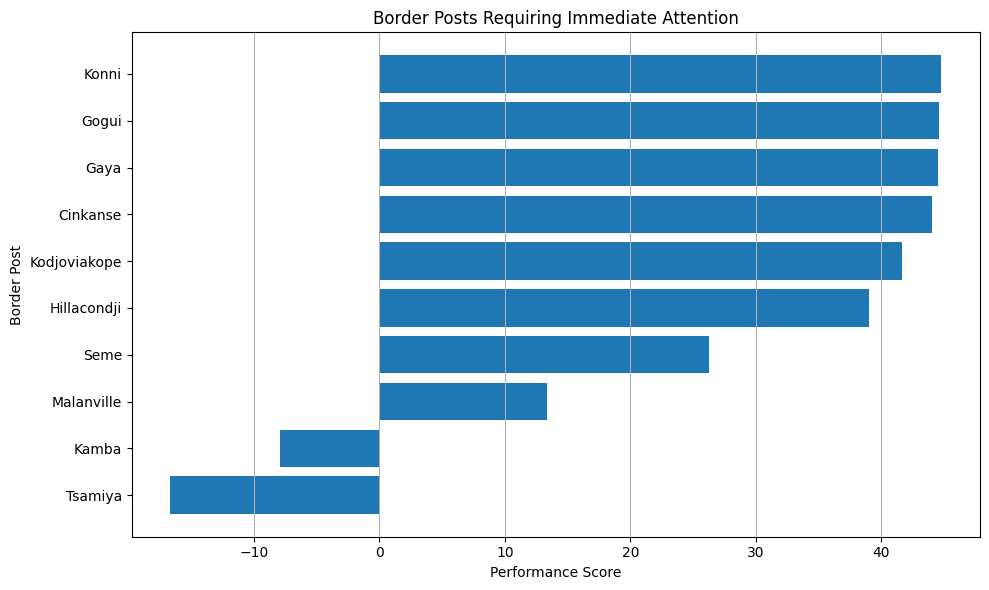

In [68]:
# ============================================================
# Chapter 12 - Bottom Border Performance Chart
# ============================================================

plt.figure(figsize=(10,6))

plt.barh(

    bottom_borders["Border_Post"],

    bottom_borders["Performance_Score"]

)

plt.title("Border Posts Requiring Immediate Attention")

plt.xlabel("Performance Score")

plt.ylabel("Border Post")

plt.grid(axis="x")

plt.tight_layout()

plt.show()

# Operational Recommendations

Border performance analysis provides valuable guidance for operational decision-making.

The following recommendations are generated based on the performance classification assigned to each border post.

In [69]:
# ============================================================
# Chapter 13 - Operational Recommendations
# ============================================================

recommendations = []

for _, row in scorecard.iterrows():

    if row["Performance_Category"] == "Excellent":

        action = "Maintain current operational strategy and document best practices."

    elif row["Performance_Category"] == "Good":

        action = "Continue monitoring and pursue incremental operational improvements."

    elif row["Performance_Category"] == "Needs Improvement":

        action = "Review staffing levels, inspection procedures, and processing efficiency."

    else:

        action = "Immediate management intervention recommended. Review staffing, infrastructure, security, and operational procedures."

    recommendations.append(action)

scorecard["Recommendation"] = recommendations

scorecard.head()

,Border_Post,Transactions,Revenue,Trade_Value,Avg_Queue,Avg_Processing,Avg_Efficiency,High_Risk,Security_Incidents,Performance_Score,Performance_Category,Recommendation
0,Jibia,2288,15509998.32,1.213439e+08,22.46,44.35,83.15,590,196,57.72,Excellent,Maintain current operational strategy and docu...
1,Illela,2636,18387635.49,1.413604e+08,22.12,43.75,83.56,654,244,56.75,Excellent,Maintain current operational strategy and docu...
2,Praia Port,2451,16670672.17,1.305909e+08,22.46,44.29,83.23,625,235,56.68,Excellent,Maintain current operational strategy and docu...
3,Paga,2713,18514492.85,1.447276e+08,22.49,44.17,83.33,678,223,56.51,Excellent,Maintain current operational strategy and docu...
4,Aflao,2612,18425257.09,1.405737e+08,22.57,44.31,83.19,659,234,56.29,Excellent,Maintain current operational strategy and docu...


## Executive Border Performance Scorecard

The executive scorecard combines operational performance indicators with management recommendations.

This consolidated report provides decision-makers with a concise overview of border performance and suggested actions.

In [70]:
# ============================================================
# Chapter 14 - Executive Scorecard
# ============================================================

executive_scorecard = scorecard[[

    "Border_Post",

    "Performance_Score",

    "Performance_Category",

    "Recommendation"

]]

executive_scorecard

,Border_Post,Performance_Score,Performance_Category,Recommendation
0,Jibia,57.72,Excellent,Maintain current operational strategy and docu...
1,Illela,56.75,Excellent,Maintain current operational strategy and docu...
2,Praia Port,56.68,Excellent,Maintain current operational strategy and docu...
3,Paga,56.51,Excellent,Maintain current operational strategy and docu...
4,Aflao,56.29,Excellent,Maintain current operational strategy and docu...
5,Elubo,55.56,Excellent,Maintain current operational strategy and docu...
6,Amdallai,55.34,Excellent,Maintain current operational strategy and docu...
7,Noe,55.33,Excellent,Maintain current operational strategy and docu...
8,Sao Domingos,55.04,Excellent,Maintain current operational strategy and docu...
9,Pogo,54.77,Good,Continue monitoring and pursue incremental ope...


## Export Performance Reports

Export the border performance scorecard and executive recommendations for use in Power BI dashboards, Streamlit applications, and management reporting.

In [71]:
# ============================================================
# Chapter 15 - Export Reports
# ============================================================

scorecard.to_csv(

    "border_performance_scorecard.csv",

    index=False

)

executive_scorecard.to_csv(

    "executive_border_scorecard.csv",

    index=False

)

print("Border performance reports exported successfully.")

Border performance reports exported successfully.


# Performance Category Summary

This section summarizes the number of border posts assigned to each performance category.

The summary provides management with an overall assessment of operational performance across the border network and helps identify whether improvement efforts should focus on a few locations or require broader organizational attention.

In [72]:
# ============================================================
# Chapter 16 - Performance Category Summary
# ============================================================

category_summary = (

    scorecard.groupby("Performance_Category")

    .agg(

        Number_of_Borders=("Border_Post","count"),

        Average_Performance=("Performance_Score","mean")

    )

    .round(2)

)

category_summary

,Number_of_Borders,Average_Performance
Performance_Category,,
Critical,4,3.75
Excellent,9,56.14
Good,5,50.59
Needs Improvement,6,43.09


# Distribution of Border Performance Categories

The following visualization illustrates how border posts are distributed across the four operational performance categories.

This overview assists decision-makers in evaluating the overall operational health of the border system.

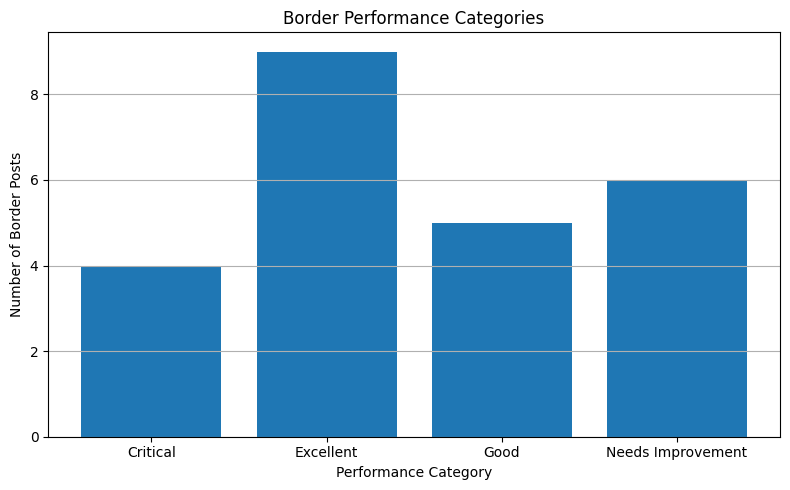

In [73]:
# ============================================================
# Chapter 17 - Performance Category Chart
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(

    category_summary.index,

    category_summary["Number_of_Borders"]

)

plt.title("Border Performance Categories")

plt.xlabel("Performance Category")

plt.ylabel("Number of Border Posts")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

# Management Action Matrix

Each performance category is linked to a recommended management action.

The objective is to convert analytical findings into practical operational decisions that support border management and strategic planning.

In [74]:
# ============================================================
# Chapter 18 - Management Action Matrix
# ============================================================

action_matrix = pd.DataFrame({

    "Performance_Category":[

        "Excellent",
        "Good",
        "Needs Improvement",
        "Critical"

    ],

    "Recommended_Action":[

        "Maintain current strategy and document best practices.",

        "Continue monitoring and pursue continuous improvement.",

        "Review staffing, inspection procedures, and operational processes.",

        "Immediate intervention required. Increase resources and conduct operational review."

    ]

})

action_matrix

,Performance_Category,Recommended_Action
0,Excellent,Maintain current strategy and document best pr...
1,Good,Continue monitoring and pursue continuous impr...
2,Needs Improvement,"Review staffing, inspection procedures, and op..."
3,Critical,Immediate intervention required. Increase reso...


# Export Border Performance Reports

Export all scorecard datasets for integration into executive dashboards, Power BI reports, Streamlit applications, and future analytical models.

In [75]:
# ============================================================
# Chapter 19 - Export Reports
# ============================================================

scorecard.to_csv(

    "border_performance_scorecard.csv",

    index=False

)

executive_scorecard.to_csv(

    "executive_border_scorecard.csv",

    index=False

)

category_summary.to_csv(

    "performance_category_summary.csv"

)

action_matrix.to_csv(

    "management_action_matrix.csv",

    index=False

)

print("Border performance reports exported successfully.")

Border performance reports exported successfully.


# Border Performance Scorecard Summary

## Overview

This notebook developed a comprehensive Border Performance Scorecard for evaluating operational performance across ECOWAS border posts.

Multiple operational indicators were combined into a composite performance score, enabling the identification of high-performing border posts as well as locations requiring management intervention.

---

## Key Achievements

- Developed a composite Border Performance Score.
- Classified border posts into four operational performance categories.
- Ranked border posts according to operational performance.
- Generated executive recommendations for each border post.
- Produced management action matrices.
- Exported dashboard-ready analytical datasets.

---

## Business Value

The Border Performance Scorecard supports:

- Evidence-based resource allocation.
- Performance monitoring.
- Intelligence-led border management.
- Strategic operational planning.
- Continuous performance improvement.

---

## Deliverables

This notebook generated the following datasets:

- border_performance_scorecard.csv
- executive_border_scorecard.csv
- performance_category_summary.csv
- management_action_matrix.csv

These outputs provide decision-ready information for executive dashboards, Power BI, Streamlit applications, and future predictive analytics projects.